In [1]:
%matplotlib inline

In [1]:
import scanpy as sc
import scvi
import anndata as ad
import seaborn as sns
import scrnatools as rna
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import celltypist
import os
import shutil
import matplotlib as mpl

/home/joe/anaconda3/envs/fezf2-thymus-env/lib/python3.9/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/home/joe/anaconda3/envs/fezf2-thymus-env/lib/python3.9/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


In [2]:
# Setup seeds
scvi.settings.seed = 0

Global seed set to 0


In [3]:
# Setup figure params
sc.set_figure_params(figsize=(4,4),  dpi=80, dpi_save=300, facecolor="white", frameon=False)
sns.set_context("paper")
plt.rcParams['pdf.use14corefonts'] = True  # Use 14 core fonts for PDF
sns.set(font="Arial")
plt.rcParams['axes.unicode_minus'] = False

Data paths

In [4]:
rawDataPath = "/mnt/iacchus/joe/raw_data/"
processedDataPath = "/mnt/iacchus/joe/processed_data/"

# Import raw data

In [7]:
adata = sc.read(f"{rawDataPath}/Thymus/Dhalla_2020/dhalla_raw_data.h5ad")

In [8]:
adata.layers["raw_counts"] = adata.X.copy()

In [9]:
adata.obs["batch"] = adata.obs["sample"].copy()

# Preprocessing

In [10]:
# Annotate mito genes
adata.var["mt"] = adata.var_names.str.startswith("mt-")
# Subset on low detection genes
sc.pp.filter_genes(adata, min_cells=20)
# Get qc metrics for each cell, gene
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True, percent_top=None, log1p=False,)
# Subset on protein coding genes
gene_info = sc.queries.biomart_annotations("mmusculus", ["ensembl_gene_id", "external_gene_name", "gene_biotype"])
gene_info = gene_info.drop_duplicates(subset="external_gene_name")
gene_info.index = gene_info.external_gene_name
del gene_info["external_gene_name"]
gene_info = gene_info[gene_info.index.isin(adata.var_names)]
adata = adata[:, adata.var_names.isin(gene_info.index)].copy()
adata.var = adata.var.join(gene_info)
adata = adata[:, adata.var.gene_biotype.isin(["protein_coding"])].copy()

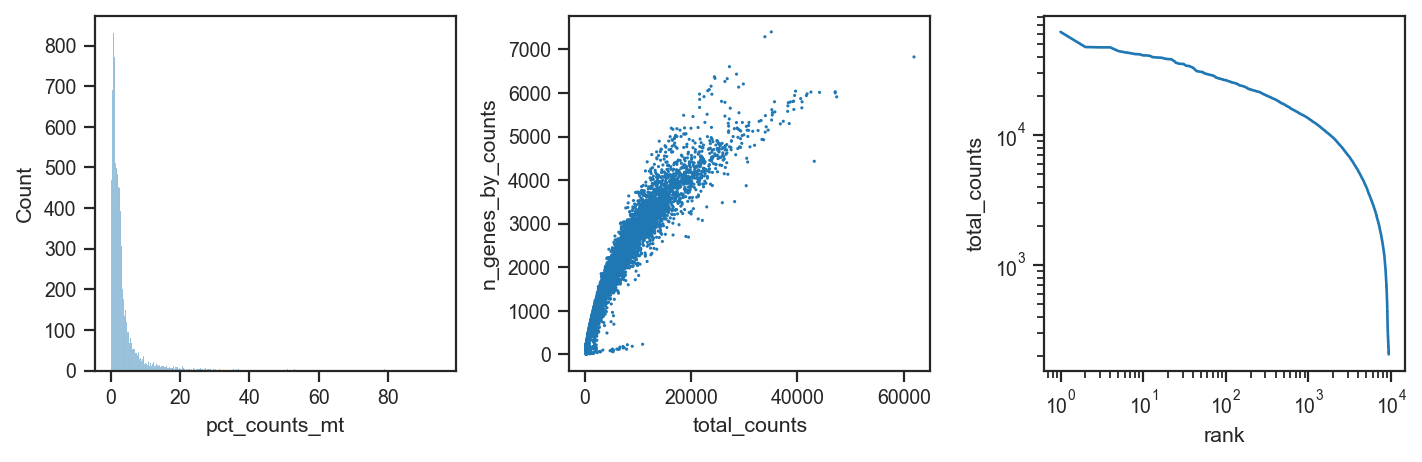

In [11]:
rna.pl.qc_plotting(
    adata,
    show_thresholds=False
)

In [12]:
# Scanpy preprocessing pipeline
adata.raw = adata
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.layers["log1p"] = adata.X.copy()

# scVI training

In [13]:
# Setup scVI model using raw counts and batch info
scvi.model.SCVI.setup_anndata(
    adata,
    layer="raw_counts",
    categorical_covariate_keys=["batch"],
)
model = scvi.model.SCVI(adata)

Unable to initialize backend 'cuda': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [14]:
# Train scVI model
model.train(
    early_stopping=True,
    max_epochs=1000,
    accelerator="gpu",
    devices="auto"
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 116/1000:  12%|█▏        | 116/1000 [03:14<24:42,  1.68s/it, v_num=1, train_loss_step=5.26e+3, train_loss_epoch=5.2e+3] 
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 5445.966. Signaling Trainer to stop.


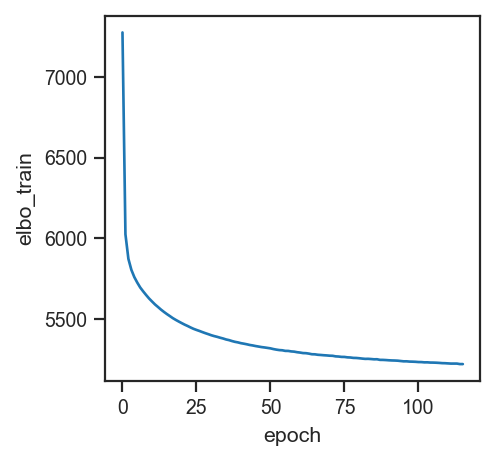

In [15]:
# Plot model ELBO
plt.figure(figsize=(3,3))
ax = sns.lineplot(model.history['elbo_train'])
plt.ylabel("elbo_train")
ax.get_legend().remove()
plt.show()

In [16]:
# get scVI latent space and normalized expression
adata.obsm["X_scVI"] = model.get_latent_representation()
adata.layers["scVI_normalized"] = model.get_normalized_expression(library_size=1e4)

# Dimensionality reduction

In [17]:
# Dimensionality reduction
sc.pp.neighbors(adata, use_rep="X_scVI")
sc.tl.umap(adata)

... storing 'qc_plot_batch' as categorical
... storing 'gene_biotype' as categorical


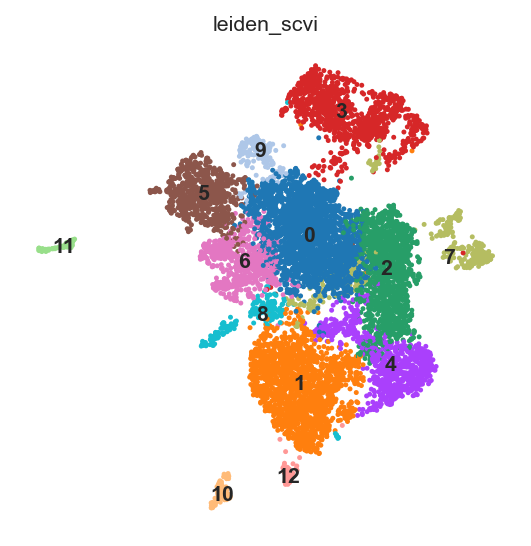

In [18]:
sc.tl.leiden(adata, key_added="leiden_scvi", resolution=0.4)
sc.pl.umap(
    adata,
    color=["leiden_scvi"],
    legend_loc="on data",
    s=20,
)

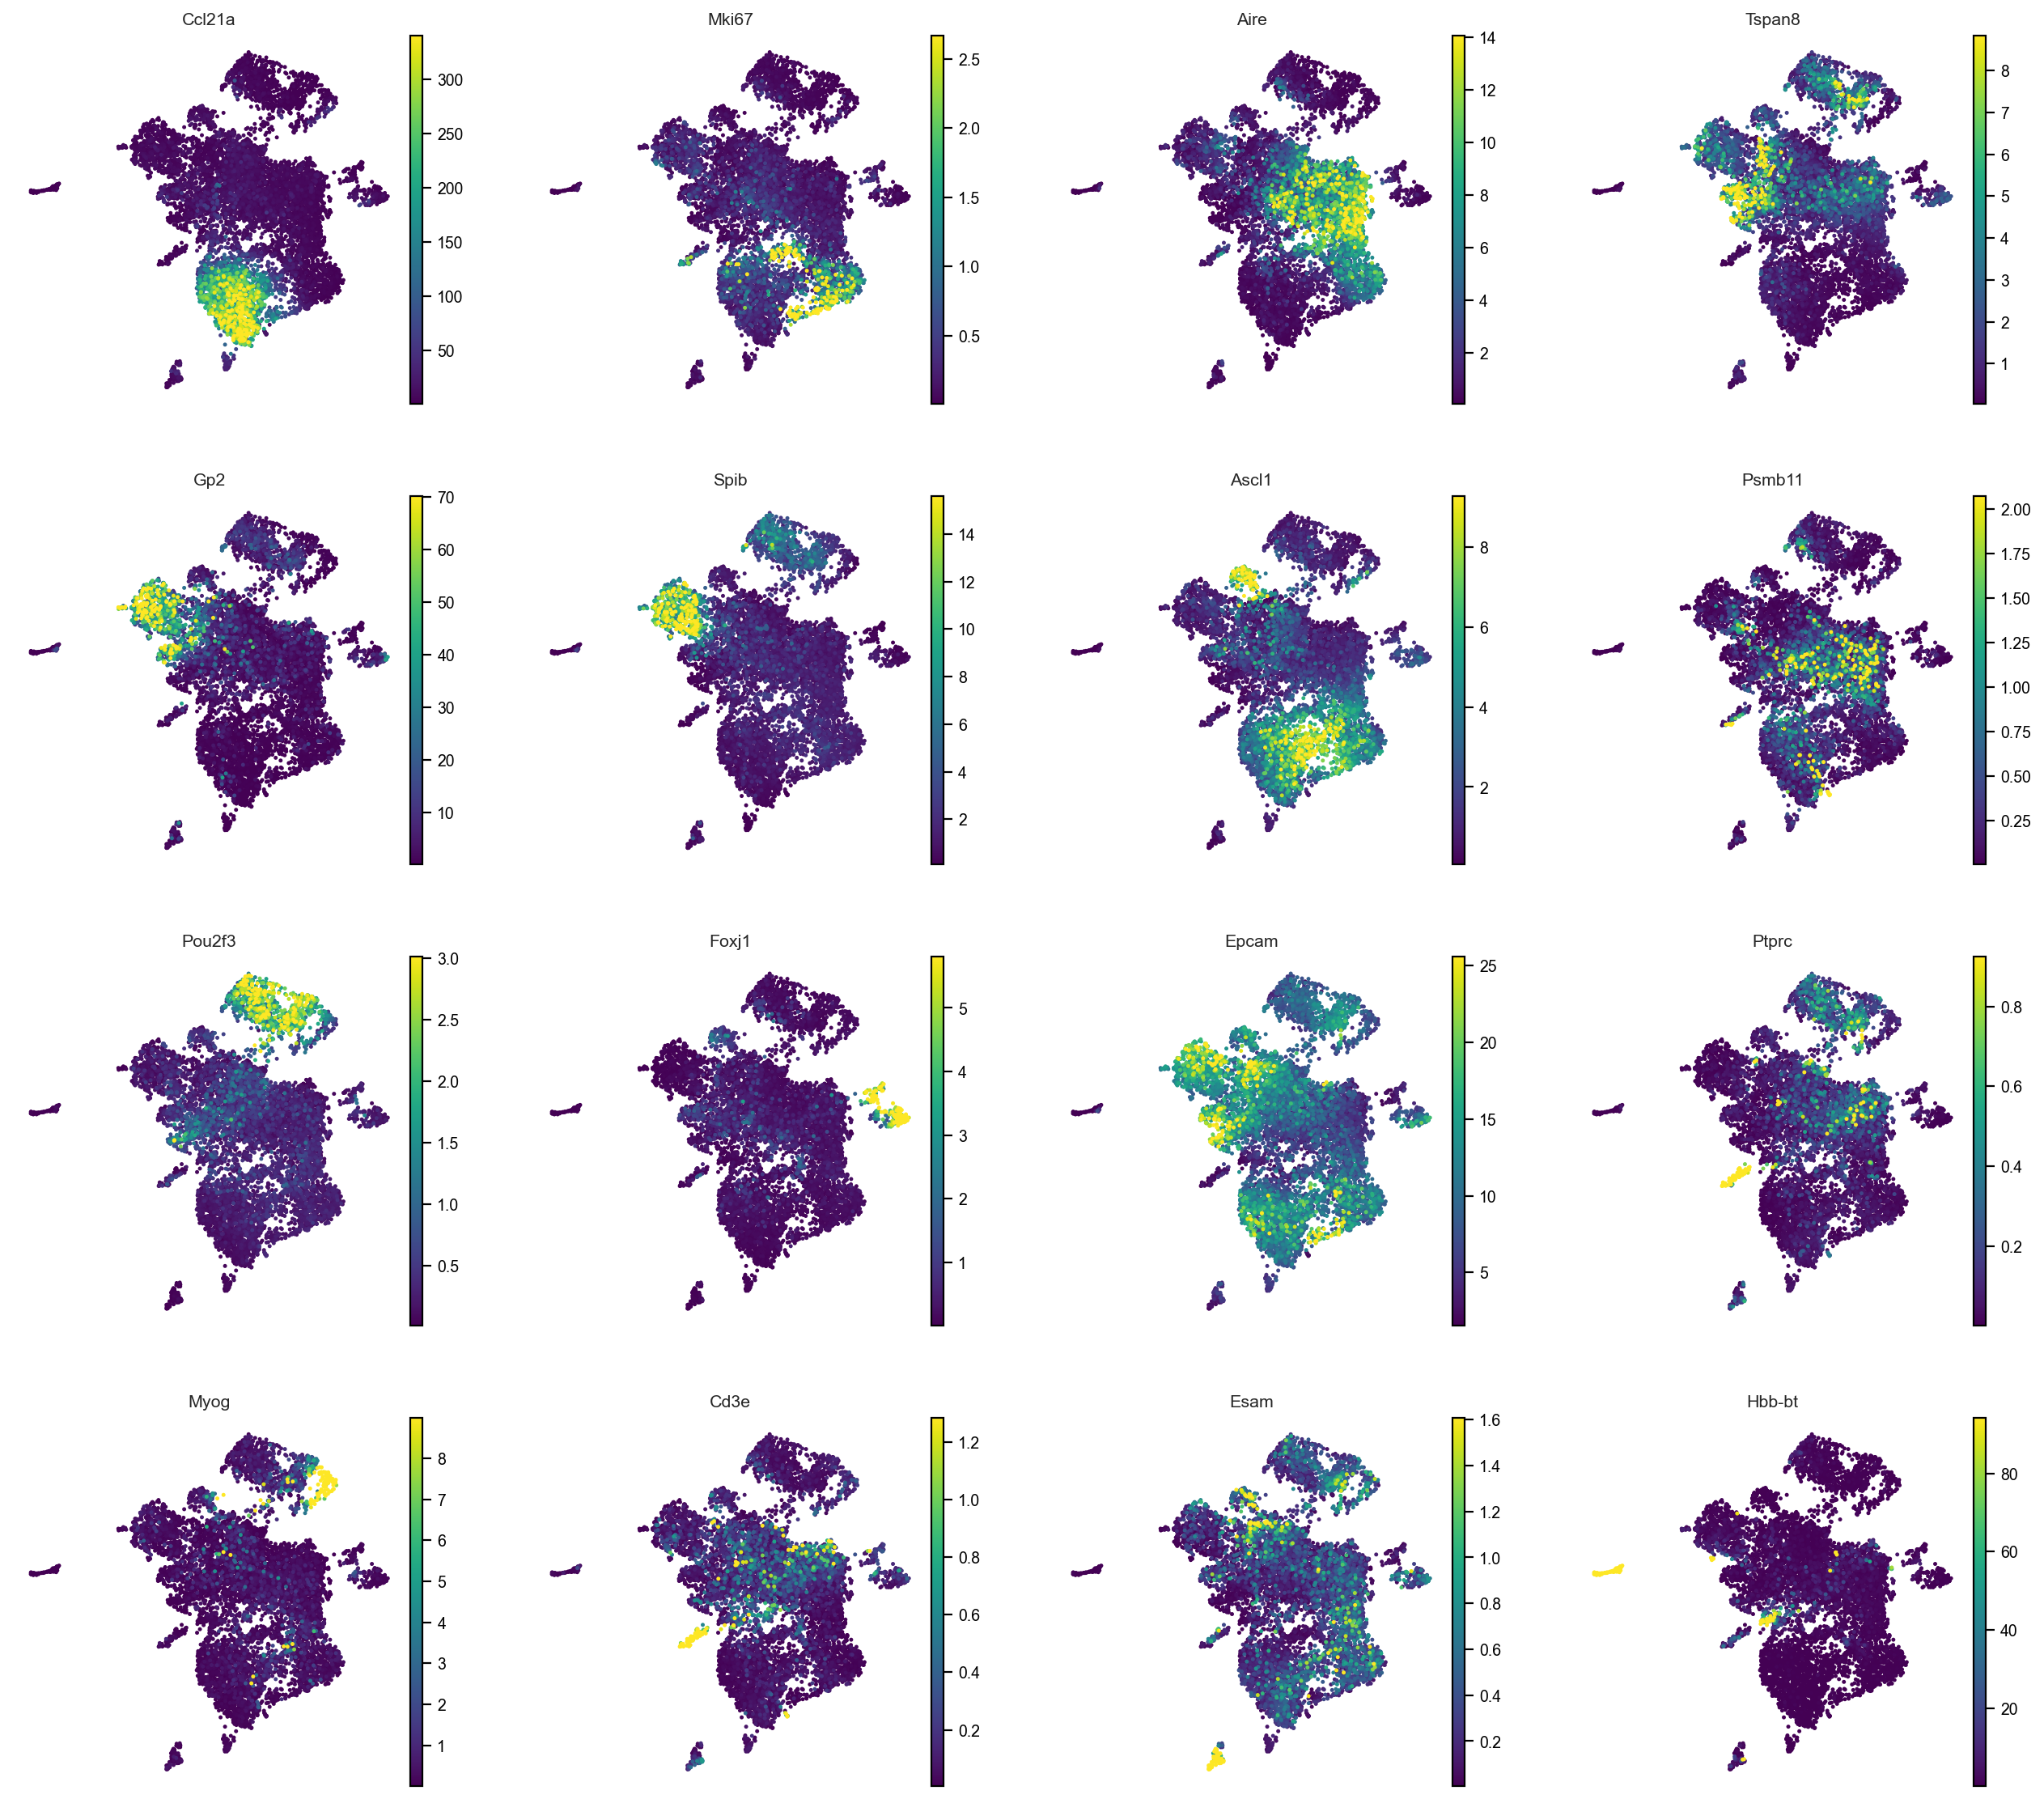

In [19]:
# Plot key marker genes
geneList = ["Ccl21a", "Mki67", "Aire", "Tspan8", "Gp2", "Spib", "Ascl1", "Psmb11", "Pou2f3", "Foxj1", "Epcam", "Ptprc", "Myog", "Cd3e", "Esam", "Hbb-bt"]
rna.pl.gene_embedding(
    adata,
    gene_list=geneList,
    layer="scVI_normalized",
    cmap="viridis",
    s=20,
)

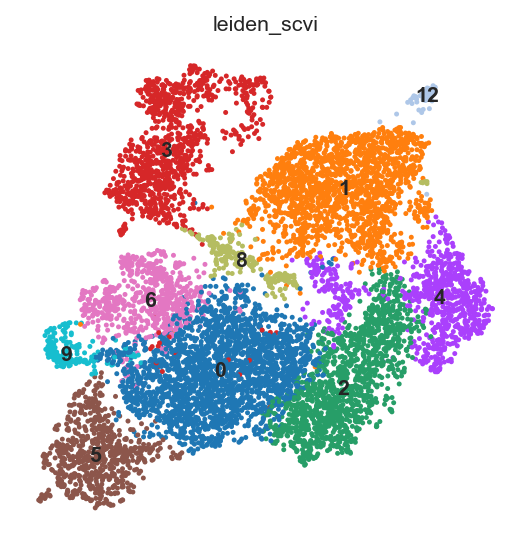

In [20]:
adata_subset = adata[~adata.obs.leiden_scvi.isin(['7', '10', '11'])].copy()
# Dimensionality reduction
sc.pp.neighbors(adata_subset, use_rep="X_scVI")
sc.tl.umap(adata_subset)
sc.pl.umap(
    adata_subset,
    color=["leiden_scvi"],
    legend_loc="on data",
    s=20,
)

# Celltypist label transfer

In [21]:
celltypist_model = celltypist.models.Model.load(f"{processedDataPath}/Fezf2_thymus_paper/michelson_thymus_celltypist_model.pkl")

In [22]:
# Ensure X contains log1p data
adata_subset.X = adata_subset.layers["log1p"].copy()
# Get celltypist predictions
predictions = celltypist.annotate(
    adata_subset,
    model=celltypist_model,
    majority_voting=True
)

🔬 Input data has 8883 cells and 15756 genes
🔗 Matching reference genes in the model
🧬 4219 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 10
🗳️ Majority voting the predictions
✅ Majority voting done!


In [23]:
adata_subset = predictions.to_adata()

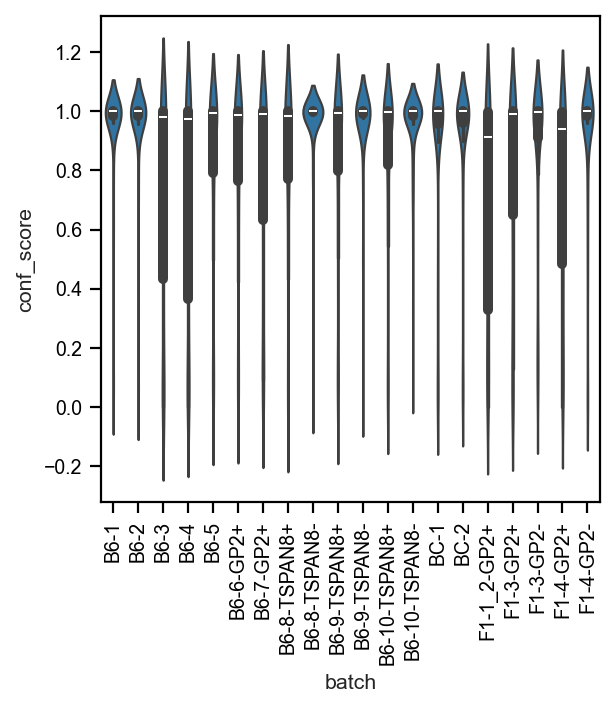

In [24]:
ax = sns.violinplot(
    adata_subset.obs,
    x="batch",
    y="conf_score",
)
plt.xticks(rotation=90)
plt.show()

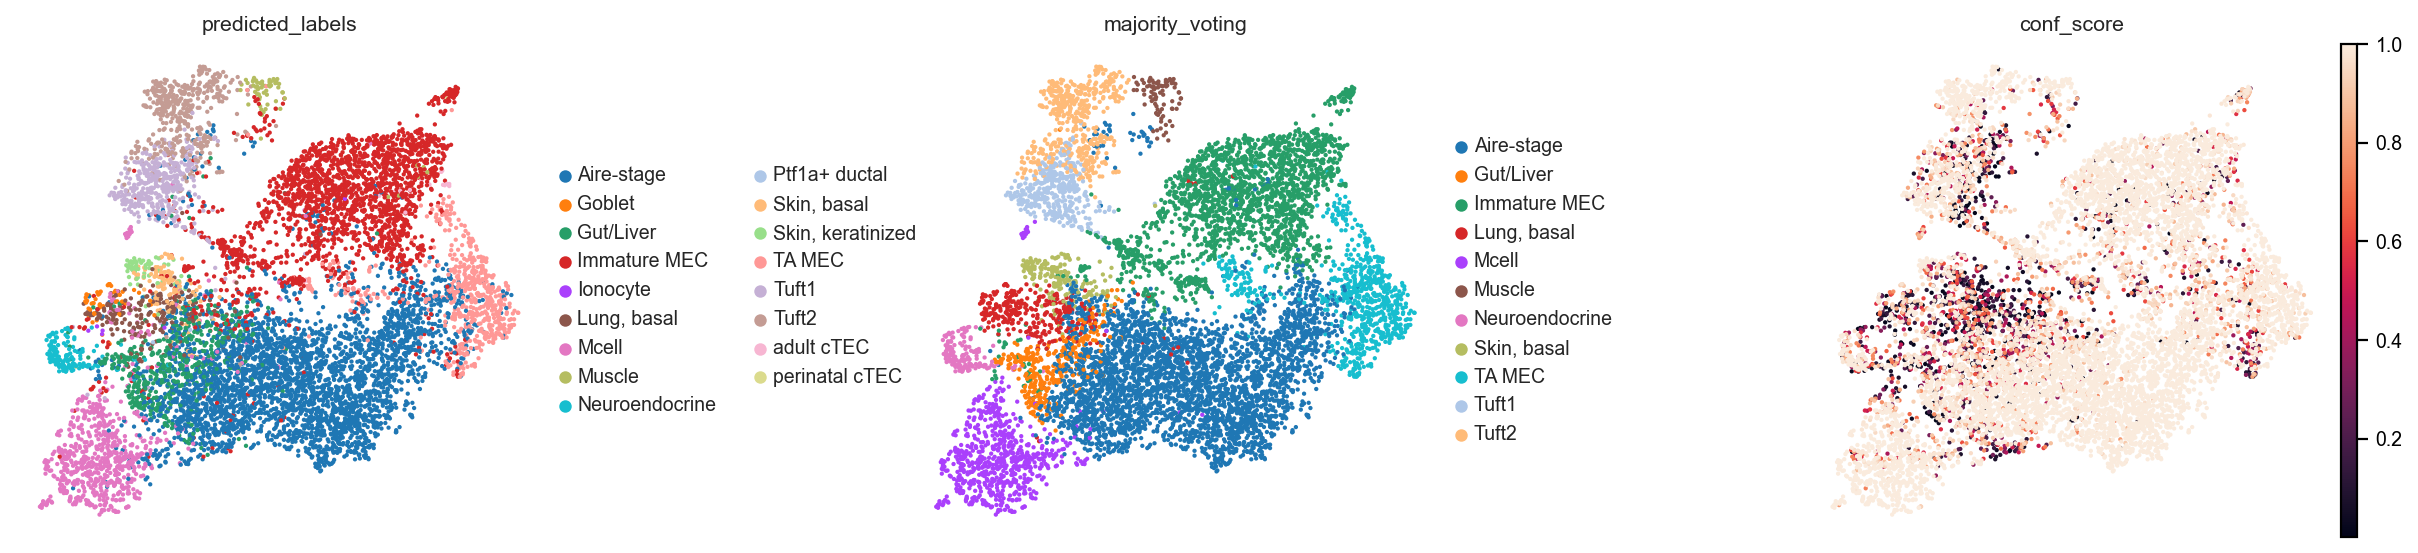

In [25]:
sc.pl.umap(
    adata_subset,
    color=["predicted_labels", "majority_voting", "conf_score"],
    s=15,
    wspace=0.55
)

# Save data

In [26]:
# Check save paths
if not os.path.isdir(f"{processedDataPath}/Fezf2_thymus_paper/scVI_models"):
    os.makedirs(f"{processedDataPath}/Fezf2_thymus_paper/scVI_models")
    
if not os.path.isdir(f"{processedDataPath}/Fezf2_thymus_paper/h5ad_files"):
    os.makedirs(f"{processedDataPath}/Fezf2_thymus_paper/h5ad_files")
    
if os.path.isdir(f"{processedDataPath}/Fezf2_thymus_paper/scVI_models/dhalla_reprocessing"):
    shutil.rmtree(f"{processedDataPath}/Fezf2_thymus_paper/scVI_models/dhalla_reprocessing")
    
model.save(f"{processedDataPath}/Fezf2_thymus_paper/scVI_models/dhalla_reprocessing")
adata.write(f"{processedDataPath}/Fezf2_thymus_paper/h5ad_files/dhalla_reprocessing.h5ad")
adata_subset.write(f"{processedDataPath}/Fezf2_thymus_paper/h5ad_files/dhalla_reprocessing_TECs.h5ad")

... storing 'gene_biotype' as categorical
... storing 'gene_biotype' as categorical


In [6]:
adata_subset = sc.read(f"{processedDataPath}/Fezf2_thymus_paper/h5ad_files/dhalla_reprocessing_TECs.h5ad")

# Fezf2-regulated genes

In [8]:
fezf2_regulated_genes = [
    "Ttr", "Krt10", "Resp18", "Fabp9", "Apoc3", "Csrnp3", "Klk1b16",
    "C530008M17Rik", "Maoa", "Smtnl1", "Calb1", "Cd177", "Timd2",
    "Pck1", "Nol4", "Bbox1"
]
fezf2_regulated_genes = [i for i in fezf2_regulated_genes if i in adata_subset.var_names]

In [9]:
adata_subset.obs.majority_voting.cat.reorder_categories(
    new_categories=[
        "Immature MEC", "TA MEC", "Aire-stage", "Muscle", "Tuft1", "Tuft2",
        "Lung, basal", "Mcell", "Neuroendocrine", "Skin, basal", "Gut/Liver"
    ],
    inplace=True
)

findfont: Font family ['Arial'] not found. Falling back to Helvetica.


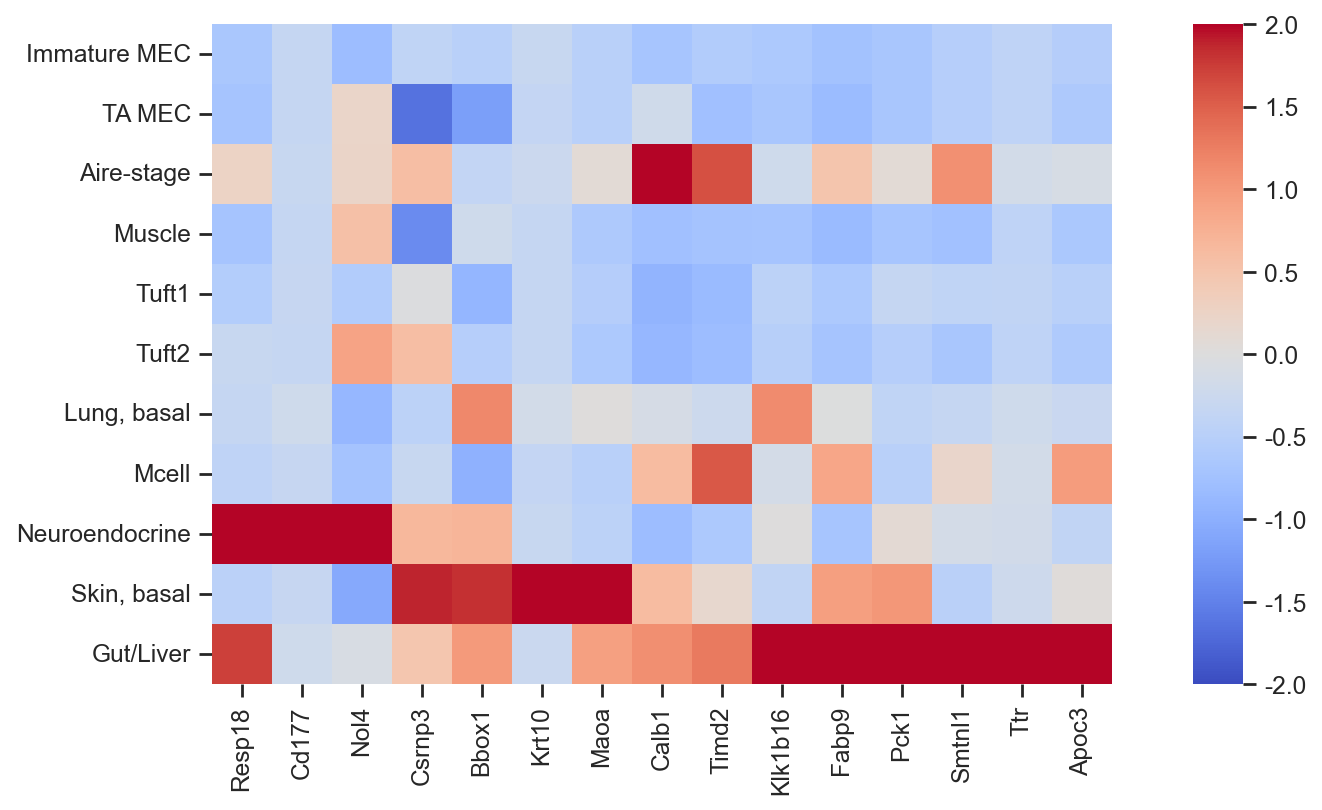

In [10]:
rna.pl.gene_heatmap(
    adata_subset,
    gene_list=fezf2_regulated_genes,
    layer="scVI_normalized",
    obs_key="majority_voting",
    z_score=1,
    cmap="coolwarm",
    vmin=-2,
    vmax=2,
    row_cluster=False,
    save_path="../../analysis/feature_plots/dhalla_data_fezf2_regulated_genes.pdf"
)

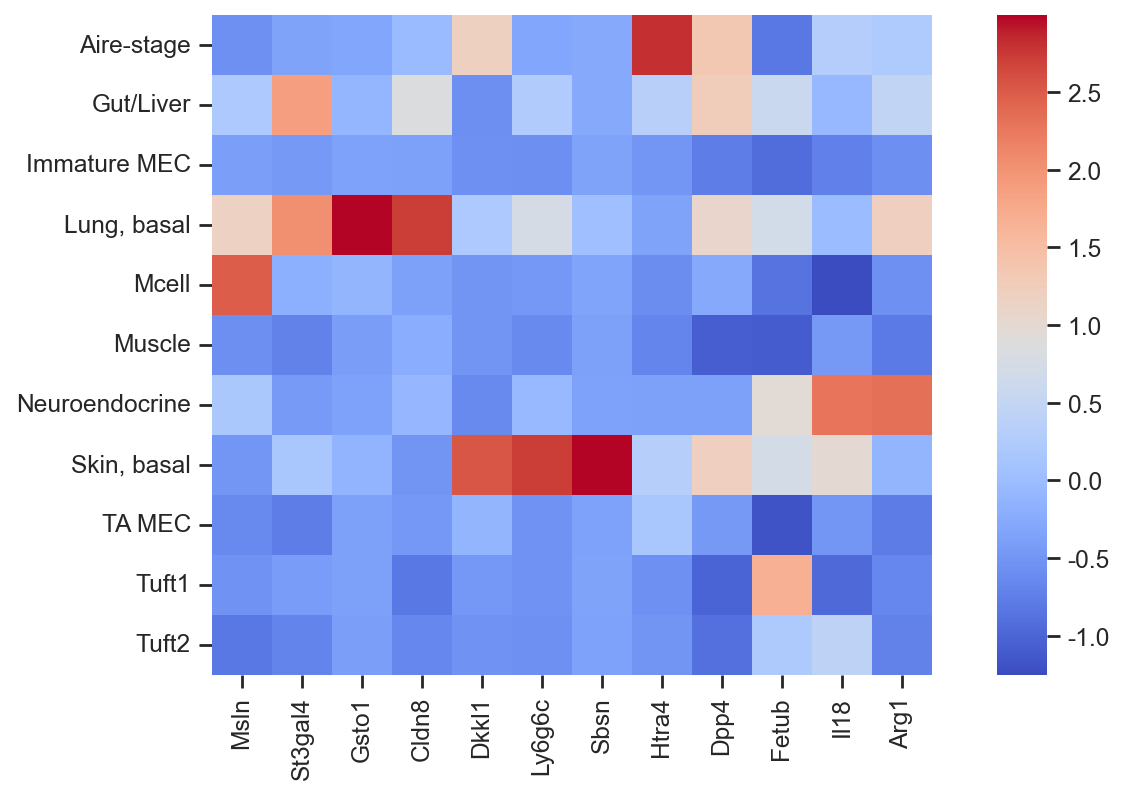

In [8]:
rna.pl.gene_heatmap(
    adata_subset,
    gene_list=["Ly6g6c", "Sbsn", "Gsto1", "Fetub", "Cldn8", "Il18", "Msln", "St3gal4", "Dkkl1", "Htra4", "Arg1", "Dpp4"],
    layer="scVI_normalized",
    obs_key="majority_voting",
    z_score=1,
    cmap="coolwarm",
    # vmin=-2,
    # vmax=2,
    row_cluster=False,
)